# Credit Card Fraud Detection - Comprehensive Analysis

This notebook provides a complete end-to-end data analysis of the Credit Card Fraud dataset. It includes:
1. **Descriptive Analysis**: Understanding the basic statistical properties of the data.
2. **Exploratory Data Analysis (EDA)**: Visualizing distributions, correlations, and class imbalances.
3. **Data Preprocessing**: Scaling and preparing the data.
4. **Predictive Analysis**: Building Machine Learning models (Logistic Regression, Random Forest, Isolation Forest).
5. **Evaluation**: Assessing models using Precision-Recall, ROC-AUC, and Confusion Matrices.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, roc_curve, auc, f1_score
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


## 1. Data Loading and Basic Inspection

In [2]:
data_path = "data/creditcard.csv"
df = pd.read_csv(data_path)
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Descriptive Analysis
Let's look at the basic statistics of the dataset, particularly focusing on the `Amount` and `Time` features, as the V1-V28 features are PCA-transformed.

In [3]:
# Basic statistics
display(df[['Time', 'Amount', 'Class']].describe())

# Check for missing values
print(f"Missing values:\n{df.isnull().sum().max()} missing values found.")

# Class imbalance ratio
fraud_count = df['Class'].sum()
normal_count = len(df) - fraud_count
print(f"\nNormal Transactions: {normal_count} ({(normal_count/len(df))*100:.2f}%)")
print(f"Fraud Transactions: {fraud_count} ({(fraud_count/len(df))*100:.2f}%)")

,Time,Amount,Class
count,284807.000000,284807.000000,284807.000000
mean,94813.859575,88.349619,0.001727
std,47488.145955,250.120109,0.041527
min,0.000000,0.000000,0.000000
25%,54201.500000,5.600000,0.000000
50%,84692.000000,22.000000,0.000000
75%,139320.500000,77.165000,0.000000
max,172792.000000,25691.160000,1.000000


Missing values:
0 missing values found.

Normal Transactions: 284315 (99.83%)
Fraud Transactions: 492 (0.17%)


## 3. Exploratory Data Analysis (EDA)

### 3.1 Class Distribution
Visualizing the extreme class imbalance.

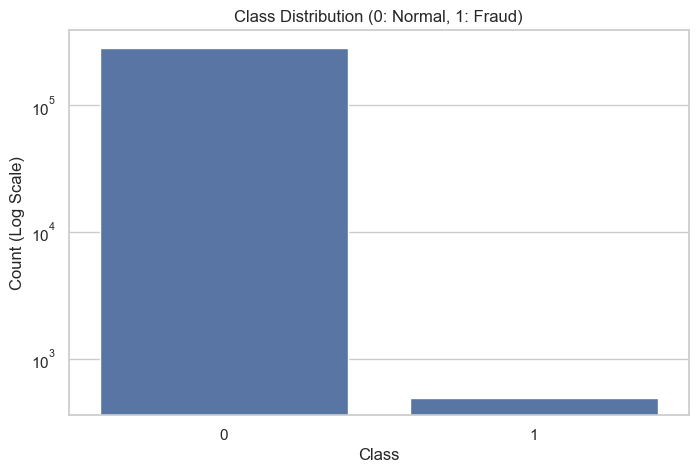

In [4]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Class', data=df)
plt.title('Class Distribution (0: Normal, 1: Fraud)')
plt.yscale('log')
plt.ylabel('Count (Log Scale)')
plt.show()

### 3.2 Transaction Amount and Time Analysis

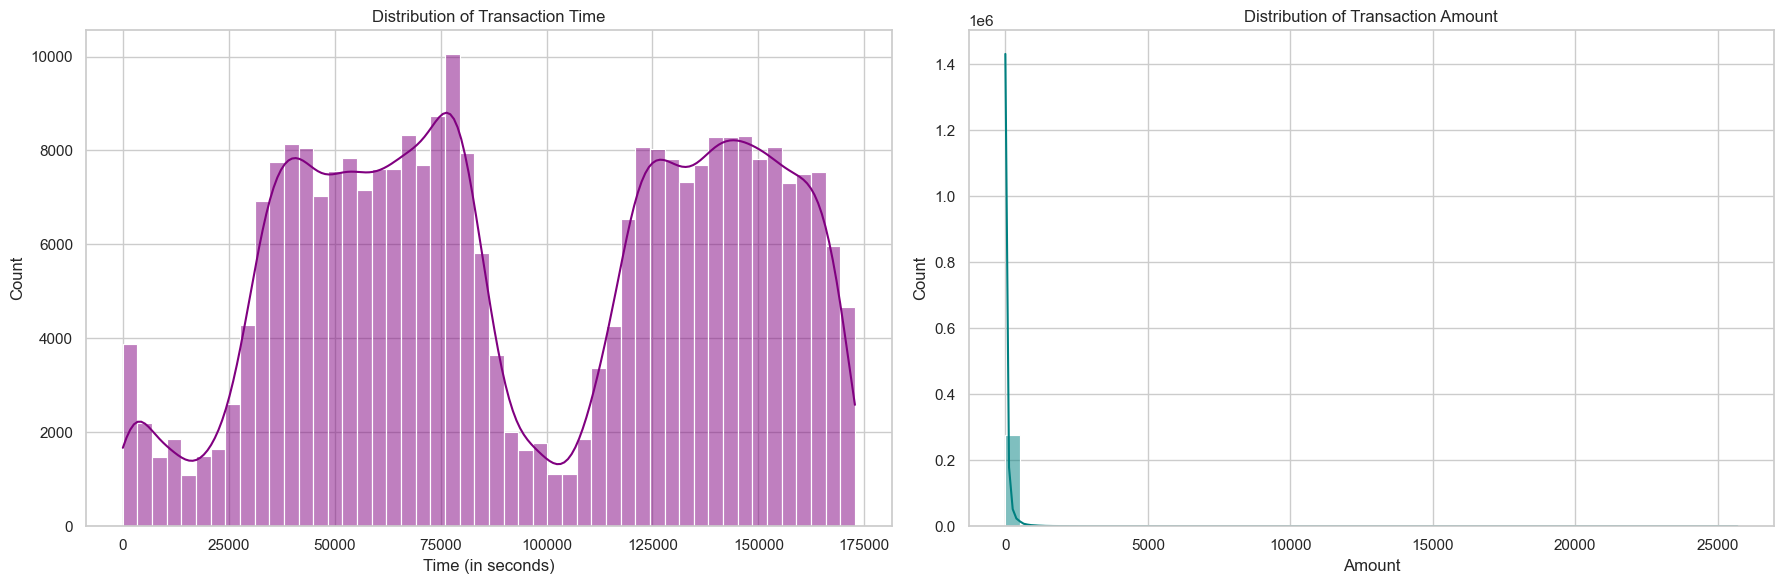

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Time distribution
sns.histplot(df['Time'], bins=50, ax=axes[0], kde=True, color='purple')
axes[0].set_title('Distribution of Transaction Time')
axes[0].set_xlabel('Time (in seconds)')

# Amount distribution
sns.histplot(df['Amount'], bins=50, ax=axes[1], kde=True, color='teal')
axes[1].set_title('Distribution of Transaction Amount')
axes[1].set_xlabel('Amount')

plt.tight_layout()
plt.show()

Let's see if the transaction amount differs between normal and fraudulent transactions.

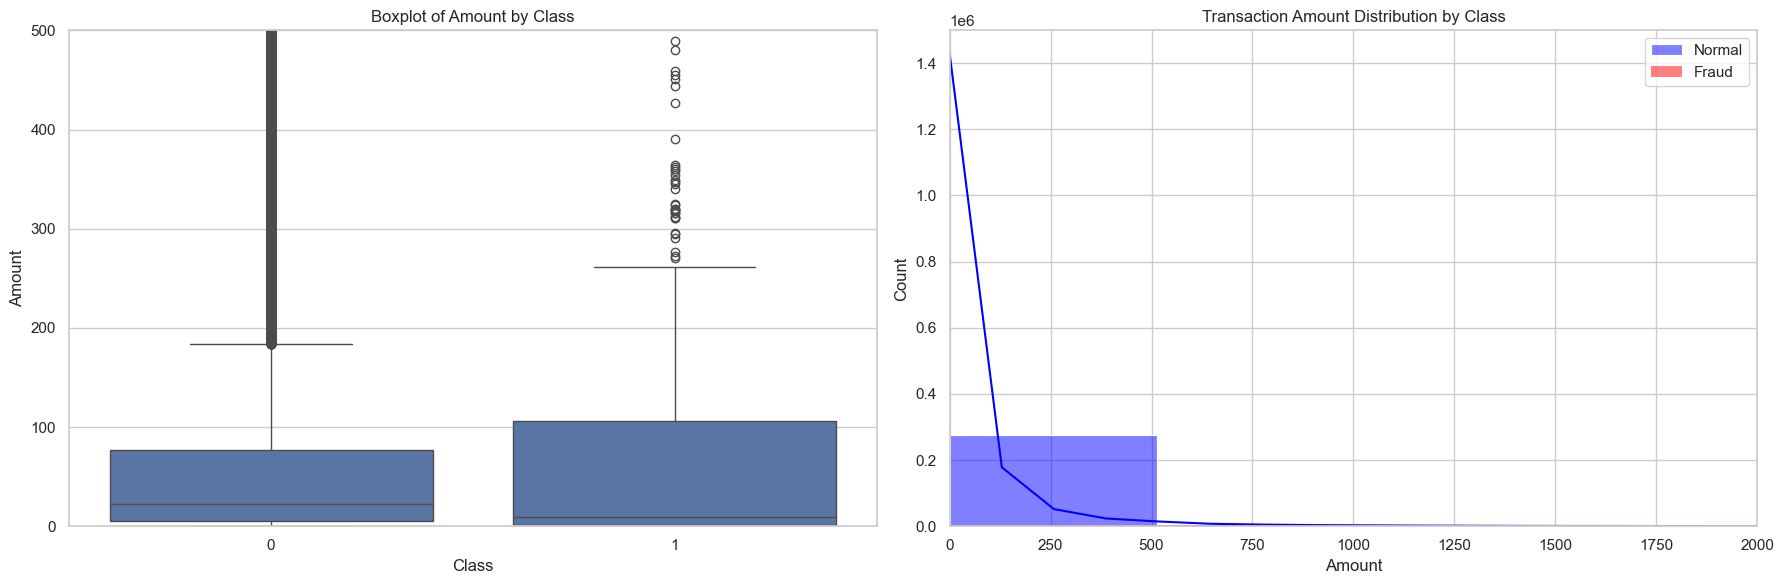

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.boxplot(x='Class', y='Amount', data=df, ax=axes[0])
axes[0].set_title('Boxplot of Amount by Class')
axes[0].set_ylim(0, 500) # Zoomed in

sns.histplot(df[df['Class'] == 0]['Amount'], bins=50, color='blue', alpha=0.5, label='Normal', kde=True, ax=axes[1])
sns.histplot(df[df['Class'] == 1]['Amount'], bins=50, color='red', alpha=0.5, label='Fraud', kde=True, ax=axes[1])
axes[1].set_xlim(0, 2000)
axes[1].legend()
axes[1].set_title('Transaction Amount Distribution by Class')

plt.tight_layout()
plt.show()

### 3.3 Correlation Heatmap
Let's see how features correlate with the target variable `Class`.

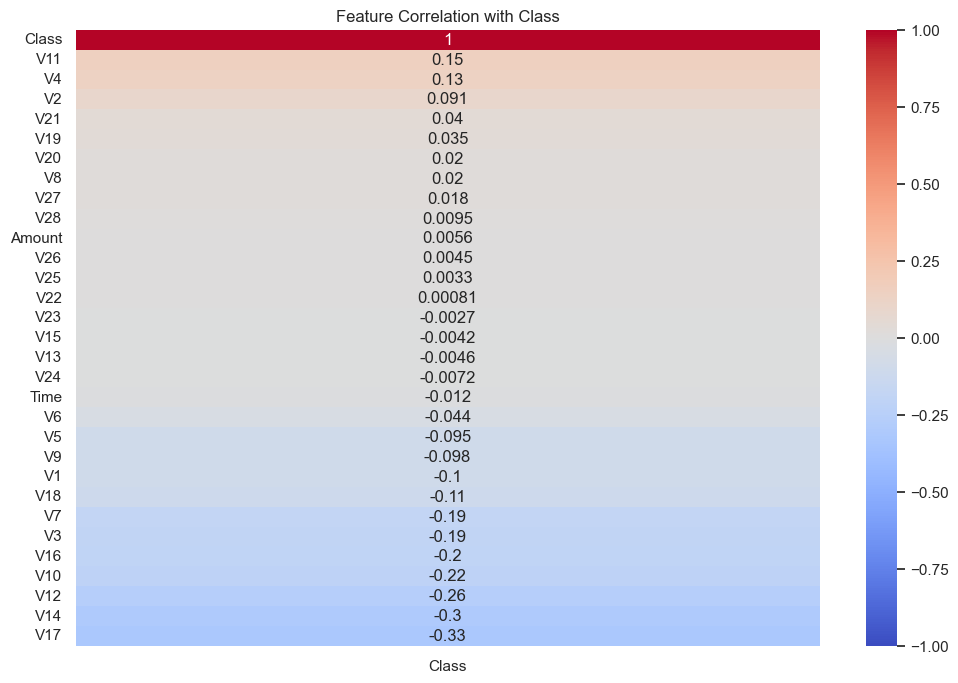

In [7]:
# We will compute the correlation matrix. Since PCA features are orthogonal, their inter-correlation is ~0.
# We focus on correlation with 'Class'.
plt.figure(figsize=(12, 8))
corr = df.corr()
sns.heatmap(corr[['Class']].sort_values(by='Class', ascending=False), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation with Class')
plt.show()

## 4. Data Preprocessing
We need to scale the `Time` and `Amount` features, as the PCA features (V1-V28) are already scaled.

In [8]:
scaler = StandardScaler()
df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = scaler.fit_transform(df['Time'].values.reshape(-1,1))

df.drop(['Time', 'Amount'], axis=1, inplace=True)

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training Set: {X_train.shape}")
print(f"Testing Set: {X_test.shape}")

Training Set: (227845, 30)
Testing Set: (56962, 30)


## 5. Predictive Analysis & Modeling
We will evaluate three models:
1. Logistic Regression (with SMOTE/Undersampling)
2. Random Forest (with Class Weights)
3. Isolation Forest (Anomaly Detection)

### Helper Function for Evaluation

In [9]:
def evaluate_model(y_true, y_pred, y_probs, model_name):
    print(f"\n{'='*50}\nEvaluation for {model_name}\n{'='*50}")
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("\nClassification Report:\n", classification_report(y_true, y_pred))
    
    if y_probs is not None:
        roc_auc = roc_auc_score(y_true, y_probs)
        print(f"ROC-AUC Score: {roc_auc:.4f}\n")
        
        precision, recall, _ = precision_recall_curve(y_true, y_probs)
        fpr, tpr, _ = roc_curve(y_true, y_probs)
        
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))
        
        # ROC Curve
        axes[0].plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.4f})')
        axes[0].plot([0, 1], [0, 1], 'k--')
        axes[0].set_xlabel('False Positive Rate')
        axes[0].set_ylabel('True Positive Rate')
        axes[0].set_title(f'{model_name} - ROC Curve')
        axes[0].legend()
        
        # PR Curve
        pr_auc = auc(recall, precision)
        axes[1].plot(recall, precision, label=f'PR curve (area = {pr_auc:.4f})')
        axes[1].set_xlabel('Recall')
        axes[1].set_ylabel('Precision')
        axes[1].set_title(f'{model_name} - Precision-Recall Curve')
        axes[1].legend()
        
        plt.show()

### Model 1: Logistic Regression with SMOTE and Undersampling
Since the data is highly imbalanced, standard Logistic Regression will fail to detect fraud. We synthetically generate fraud cases (SMOTE) and undersample normal cases.

Training Logistic Regression Pipeline...

Evaluation for Logistic Regression (SMOTE + UnderSampling)
Confusion Matrix:
 [[56077   787]
 [   10    88]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.10      0.90      0.18        98

    accuracy                           0.99     56962
   macro avg       0.55      0.94      0.59     56962
weighted avg       1.00      0.99      0.99     56962

ROC-AUC Score: 0.9678



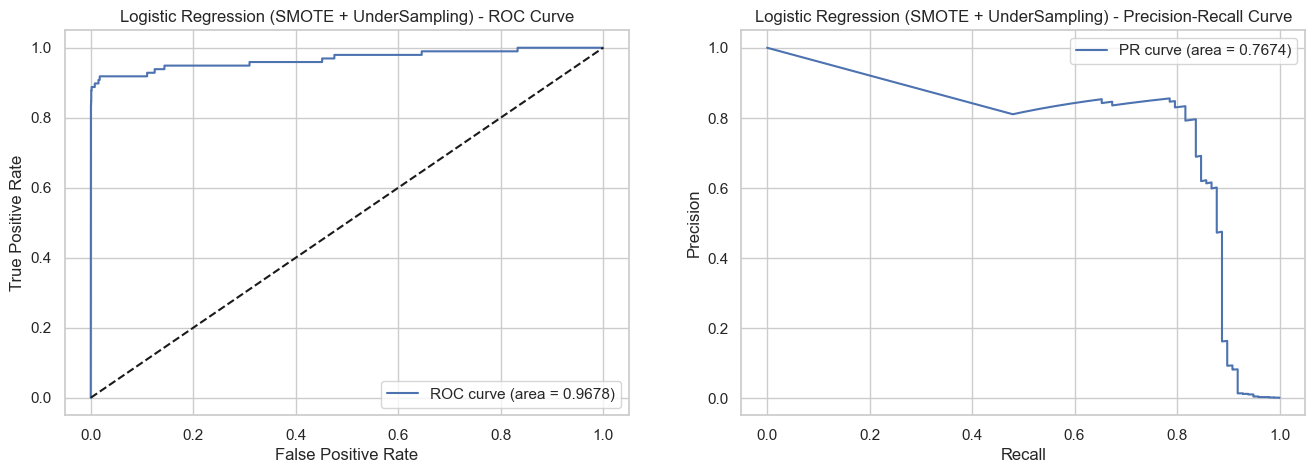

In [10]:
smote = SMOTE(sampling_strategy=0.1, random_state=42)
under = RandomUnderSampler(sampling_strategy=0.5, random_state=42)
log_reg_pipeline = ImbPipeline(steps=[('smote', smote), ('under', under), ('classifier', LogisticRegression(max_iter=1000))])

print("Training Logistic Regression Pipeline...")
log_reg_pipeline.fit(X_train, y_train)

y_pred_lr = log_reg_pipeline.predict(X_test)
y_probs_lr = log_reg_pipeline.predict_proba(X_test)[:, 1]

evaluate_model(y_test, y_pred_lr, y_probs_lr, "Logistic Regression (SMOTE + UnderSampling)")

### Model 2: Random Forest Classifier
Random Forests can handle non-linear relationships well. To deal with imbalance, we use `class_weight='balanced'`.

Training Random Forest...

Evaluation for Random Forest
Confusion Matrix:
 [[56861     3]
 [   25    73]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.9534



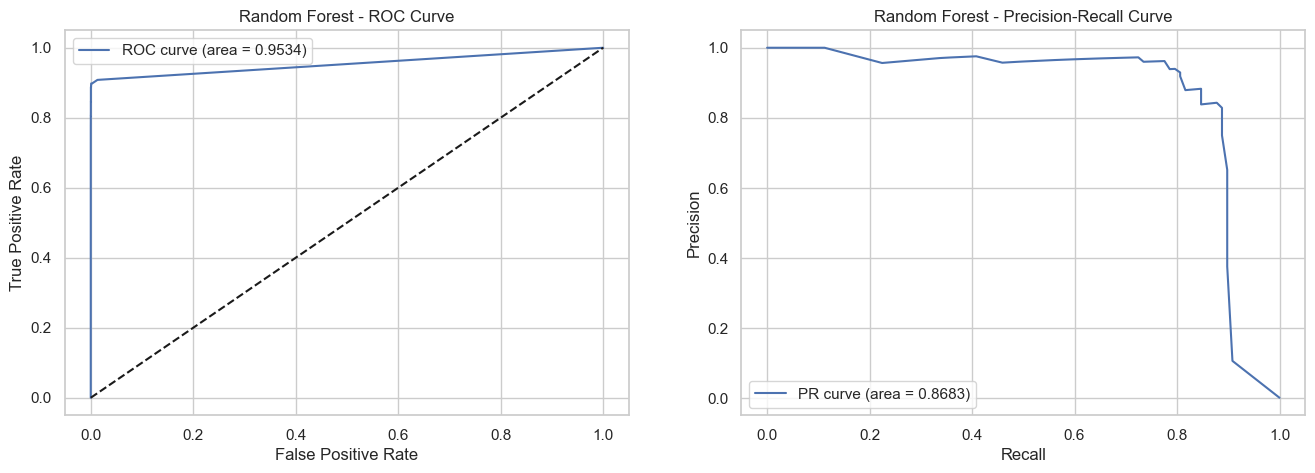

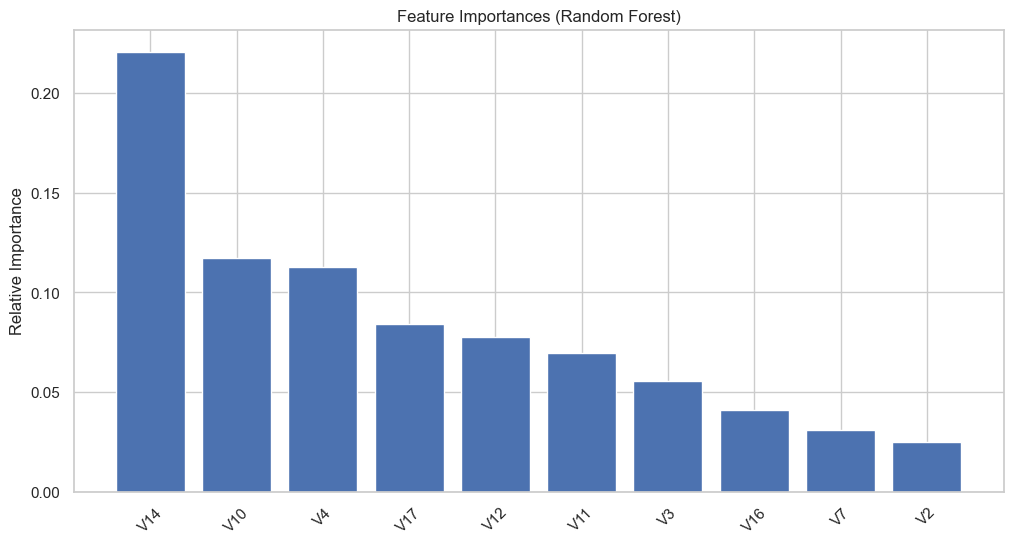

In [11]:
rf = RandomForestClassifier(n_estimators=50, random_state=42, class_weight='balanced', n_jobs=-1)
print("Training Random Forest...")
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_probs_rf = rf.predict_proba(X_test)[:, 1]

evaluate_model(y_test, y_pred_rf, y_probs_rf, "Random Forest")

# Feature Importance
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Feature Importances (Random Forest)")
plt.bar(range(10), importances[indices][:10], align="center")
plt.xticks(range(10), X_train.columns[indices][:10], rotation=45)
plt.ylabel('Relative Importance')
plt.show()

### Model 3: Isolation Forest
An unsupervised anomaly detection method. It assumes that anomalies (fraud) are few and different, making them easier to 'isolate'.

Training Isolation Forest...

Evaluation for Isolation Forest
Confusion Matrix:
 [[56797    67]
 [   62    36]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.35      0.37      0.36        98

    accuracy                           1.00     56962
   macro avg       0.67      0.68      0.68     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.9557



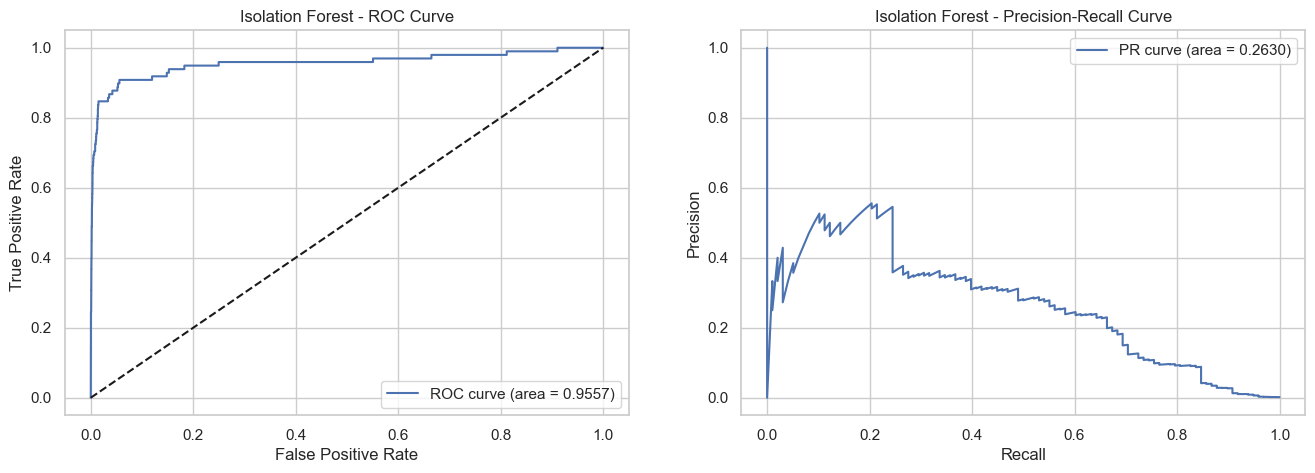

In [12]:
iso_forest = IsolationForest(n_estimators=100, max_samples=len(X_train), contamination=float(y_train.mean()), random_state=42, n_jobs=-1)
print("Training Isolation Forest...")
iso_forest.fit(X_train)

# Predictions: 1 for normal, -1 for anomaly. Convert to 0 normal, 1 anomaly.
y_pred_iso_raw = iso_forest.predict(X_test)
y_pred_iso = np.where(y_pred_iso_raw == 1, 0, 1)

# Anomaly scores
y_probs_iso = -iso_forest.score_samples(X_test)

evaluate_model(y_test, y_pred_iso, y_probs_iso, "Isolation Forest")

## 6. Conclusion
* **Logistic Regression (with SMOTE)** catches most frauds (high Recall) but suffers from false positives (low Precision).
* **Random Forest** provides the best balance of Precision and Recall, making it highly effective for a production environment where false alarms have a high cost.
* **Isolation Forest** works as a solid unsupervised baseline but does not match supervised Random Forest performance.